# IMPORT LIBRARY

In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

# CONNECTING TO DATABASE

In [3]:
load_dotenv("../.env")

conn = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connection created")

Connection created


In [4]:
customer_data = '''
    WITH 
    cust_activity AS(
        SELECT
            cm.customer_id
            ,COUNT(i.interaction_id) AS total_interaction
            ,AVG(cm.engagement_score) AS engagement_score
        FROM customers_monthly_metrics cm
        LEFT JOIN interactions i ON cm.customer_id = i.customer_id
        GROUP BY cm.customer_id),
                    
    cust_trans AS (
        SELECT
            t.customer_id
            ,p.property_type
            ,t.payment_mode
            ,t.deal_price AS total_deal_price
            ,t.transaction_id
            ,t.deal_date AS last_transaction
        FROM transactions t
        LEFT JOIN properties p ON t.property_id =  p.property_id
        WHERE EXTRACT(YEAR FROM t.deal_date)<=2024 AND t.deal_status ='Completed'
        ),
    
    cust_property_interaction AS (
        SELECT
            i.customer_id
            ,i.property_id
            ,p.property_type AS cust_property_int
        FROM interactions i
        LEFT JOIN properties p ON p.property_id = i.property_id
        WHERE EXTRACT(YEAR FROM i.event_ts)<=2024
        )


    SELECT c.customer_id
            ,c.age
            ,c.income_band
            ,c.segment
            ,c.household_size
            ,c.home_city
            ,c.signup_date
            ,ca.total_interaction
            ,ca.engagement_score
            ,c.acquisition_channel
            ,ct.transaction_id
            ,ct.payment_mode
            ,ct.total_deal_price
            ,ct.property_type
            ,cp.cust_property_int
    FROM customers c
    LEFT JOIN cust_trans ct ON ct.customer_id = c.customer_id
    LEFT JOIN cust_activity ca ON ca.customer_id = c.customer_id
    LEFT JOIN cust_property_interaction cp ON cp.customer_id = c.customer_id
'''

df_customer = pd.read_sql(customer_data,conn)

len(df_customer)

150835

In [13]:
df_customer = df_customer.sort_values('customer_id').reset_index(drop= True)
df_trans_cust = df_customer[df_customer['transaction_id'].notna()]
df_trans_cust = (\
    df_trans_cust
    .drop_duplicates('transaction_id')
    .drop(columns='cust_property_int')
    .sort_values('customer_id')
    .reset_index(drop = True)
)
df_non_trans_cust = df_customer[df_customer['transaction_id'].isnull()].reset_index(drop=True)
df_cust = (\
    df_customer
    .drop_duplicates('customer_id')
    .drop(columns = ['total_interaction',
                     'transaction_id', 'payment_mode',
                     'total_deal_price', 'property_type',
                     'cust_property_int']).sort_values('customer_id').reset_index(drop = True)
)



> CUSTOMER OVERVIEW

In [7]:
print(f"Number of Customer : {len(df_cust)}")
print(f"Number of Customer Transaction : {df_trans_cust['customer_id'].nunique()}")
print(f"AVG Revenue per Customer : {(df_trans_cust['total_deal_price'].sum())/(df_trans_cust['customer_id'].nunique())/1e6:,.2f} M")

Number of Customer : 8000
Number of Customer Transaction : 2941
AVG Revenue per Customer : 17.53 M


>CUSTOMER SEGMENT ANALYSIS

In [8]:
df_segment_perform = (\
    df_cust
    .groupby('segment')
    .agg(total_customer = ('customer_id','count'))
    )

df_segment_perform['customer_share'] = (
    round(df_segment_perform['total_customer']/
    (df_segment_perform['total_customer']
     .sum())*100,2)
    )

df_segment_perform['cust_trans'] = (\
    df_trans_cust
    .groupby('segment')
    ['customer_id'].nunique()
)

df_segment_perform['convertion_rate'] = (\
    round(df_segment_perform['cust_trans']/
    df_segment_perform['total_customer']
    *100,2)
)

df_segment_perform['total_earn'] = (\
    df_trans_cust
    .groupby('segment')
    ['total_deal_price'].sum())

df_segment_perform['revenue_share'] = (\
    round(df_segment_perform['total_earn']/
          (df_segment_perform['total_earn'].sum())
          *100,2)
)

df_segment_perform['avg_per_cust'] = (\
    round(df_segment_perform['total_earn']/
          df_segment_perform['cust_trans']
          *100,2)
)

df_segment_perform

,total_customer,customer_share,cust_trans,convertion_rate,total_earn,revenue_share,avg_per_cust
segment,,,,,,,
Business Buyer,850,10.62,344,40.47,6.298947e+09,12.22,1.831089e+09
End-User,4053,50.66,1365,33.68,2.308851e+10,44.80,1.691466e+09
Investor,1423,17.79,641,45.05,1.160686e+10,22.52,1.810743e+09
Renter-to-Owner,1674,20.92,591,35.30,1.054739e+10,20.46,1.784669e+09


> Segment Distribution

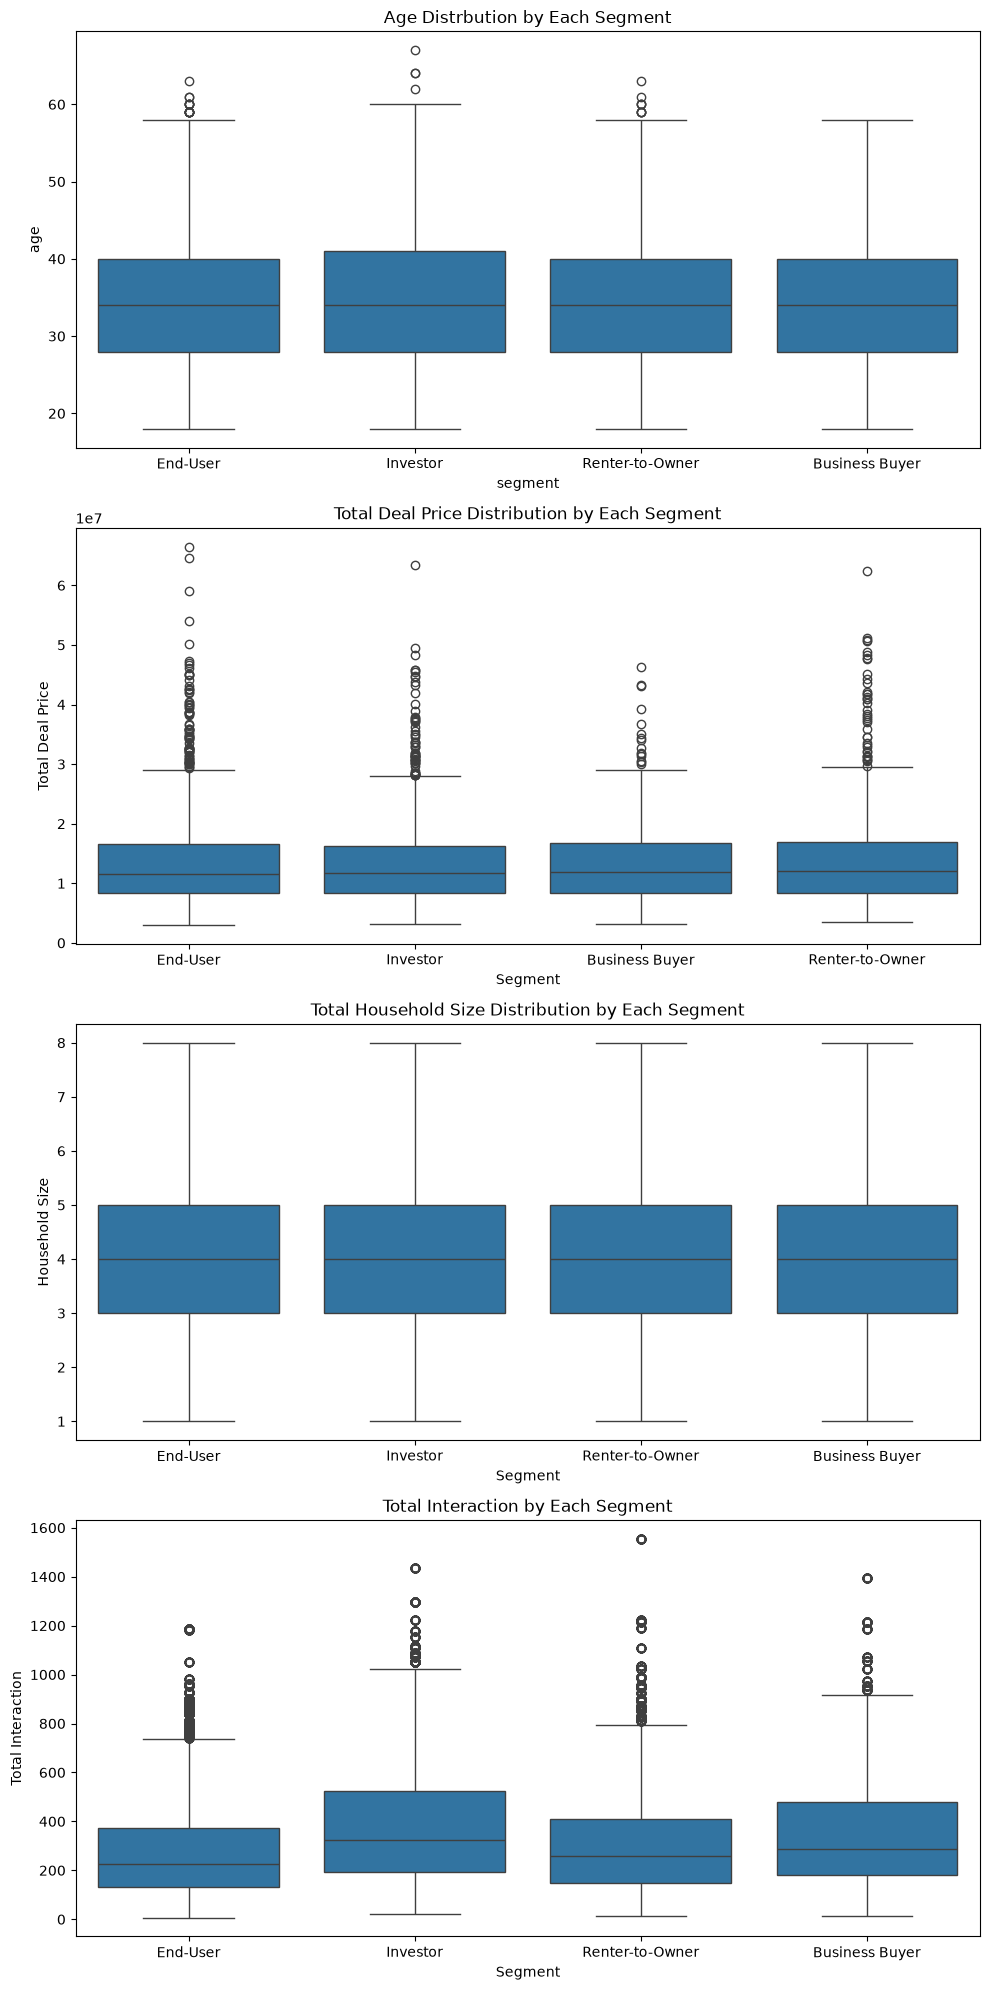

In [10]:
fig, axes = plt.subplots(4,1 ,figsize=(10,20))

sns.boxplot(
    data= df_cust
    ,x = 'segment'
    ,y = 'age'
    ,ax = axes[0]
)
axes[0].set_title('Age Distrbution by Each Segment')
axes[0].set_ylabel('age')
axes[0].set_xlabel('segment')

sns.boxplot(
    data= df_trans_cust
    ,x = 'segment'
    ,y = 'total_deal_price'
    ,ax = axes[1]
)

axes[1].set_title('Total Deal Price Distribution by Each Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total Deal Price')

sns.boxplot(
    data= df_cust
    ,x = 'segment'
    ,y = 'household_size'
    ,ax = axes[2]
)

axes[2].set_title('Total Household Size Distribution by Each Segment')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('Household Size')

sns.boxplot(
    data= df_customer
    ,x = 'segment'
    ,y = 'total_interaction'
    ,ax = axes[3]
)

axes[3].set_title('Total Interaction by Each Segment')
axes[3].set_xlabel('Segment')
axes[3].set_ylabel('Total Interaction')


plt.tight_layout()
plt.show()

In [11]:
cust_by_city = (\
    df_cust
    .groupby('home_city')
    .agg(total_customer = ('customer_id','count'))
)

cust_by_city['customer_share'] = (\
    round(cust_by_city['total_customer']/
          (cust_by_city['total_customer'].sum())*100,2)
)

def call_crosstab (df,col1,col2):
    return round(pd.crosstab(df[col1],df[col2],normalize=True)*100,2)

segment_by_city = call_crosstab(df_cust,'segment','home_city')
segment_by_property_interest = call_crosstab(df_customer,'segment','cust_property_int')
segment_by_income = call_crosstab(df_cust,'segment','income_band')
segment_by_payment_mode = call_crosstab(df_trans_cust,'segment','payment_mode')
segment_by_property_trans = call_crosstab(df_trans_cust,'segment','property_type')
segment_by_acquisition_channel = call_crosstab(df_customer,'segment','acquisition_channel')

display(cust_by_city)
display(segment_by_city)
display(segment_by_property_interest)
display(segment_by_property_trans)
display(segment_by_income)
display(segment_by_payment_mode)
display(segment_by_acquisition_channel)


,total_customer,customer_share
home_city,,
Barishal,546,6.82
Chattogram,1407,17.59
Dhaka,2415,30.19
Khulna,815,10.19
Mymensingh,693,8.66
Rajshahi,760,9.50
Rangpur,691,8.64
Sylhet,673,8.41


home_city,Barishal,Chattogram,Dhaka,Khulna,Mymensingh,Rajshahi,Rangpur,Sylhet
segment,,,,,,,,
Business Buyer,0.70,2.00,3.21,0.90,0.81,1.00,0.98,1.03
End-User,3.58,8.99,14.98,5.18,4.36,4.88,4.62,4.09
Investor,1.21,2.89,5.45,1.92,1.60,1.84,1.34,1.54
Renter-to-Owner,1.34,3.71,6.55,2.19,1.89,1.79,1.70,1.76


cust_property_int,Apartment,Commercial,House,Land
segment,,,,
Business Buyer,6.79,0.93,3.23,1.37
End-User,24.38,3.61,11.43,4.90
Investor,12.34,1.80,5.87,2.46
Renter-to-Owner,11.43,1.67,5.50,2.28


property_type,Apartment,Commercial,House,Land
segment,,,,
Business Buyer,6.80,0.96,3.26,1.39
End-User,25.82,3.48,11.56,4.20
Investor,12.71,1.53,5.89,2.38
Renter-to-Owner,11.59,1.53,4.92,1.98


income_band,High,Low,Lower-Mid,Mid,Unknown,Upper-Mid
segment,,,,,,
Business Buyer,0.86,1.98,2.75,3.18,0.52,1.34
End-User,2.82,9.85,12.62,14.58,2.92,7.86
Investor,0.96,3.60,4.51,4.59,1.05,3.08
Renter-to-Owner,1.26,3.95,5.16,6.06,1.36,3.12


payment_mode,Cash,Installment,Mortgage,Unknown
segment,,,,
Business Buyer,4.12,2.22,5.91,0.16
End-User,16.80,6.42,21.22,0.62
Investor,8.62,3.51,10.12,0.27
Renter-to-Owner,7.52,3.16,9.10,0.24


acquisition_channel,Broker Network,Email,Facebook,Marketplace,Organic,Paid Search,Referral
segment,,,,,,,
Business Buyer,1.76,0.93,2.31,1.33,2.75,1.87,1.38
End-User,5.81,3.34,8.53,3.76,10.16,7.38,5.35
Investor,2.88,1.59,4.07,2.12,4.92,4.37,2.52
Renter-to-Owner,2.31,1.61,3.82,1.90,5.05,4.01,2.18
